     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

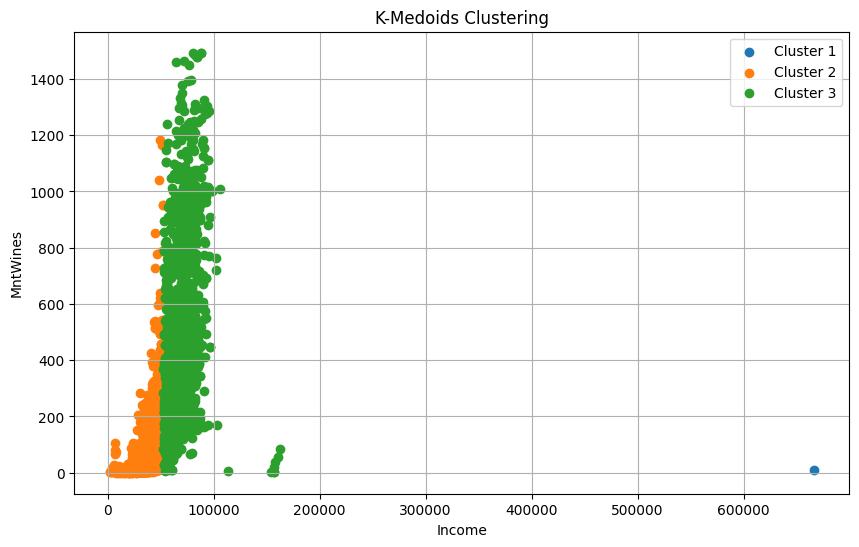

In [5]:
!pip install pyclustering
import pandas as pd
import matplotlib.pyplot as plt

from pyclustering.cluster.kmedoids import kmedoids

df = pd.read_csv(
    "marketing_campaign.csv",
    sep="\t"
)

print(df.head())

print("\nMissing Values")
print(df.isnull().sum())

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

X = df[
    [
        "Income",
        "MntWines"
    ]
]

data = X.values.tolist()

initial_medoids = [0, 100, 200]

kmedoids_instance = kmedoids(
    data,
    initial_medoids
)

kmedoids_instance.process()

clusters = kmedoids_instance.get_clusters()

df["Cluster"] = -1

for cluster_id, cluster_points in enumerate(clusters):

    for point in cluster_points:

        df.loc[df.index[point], "Cluster"] = cluster_id

print("\nCluster Summary")
print(df["Cluster"].value_counts())

for i in sorted(df["Cluster"].unique()):

    print("\n" + "="*50)
    print("CLUSTER", i + 1)
    print("="*50)

    cluster_data = df[
        df["Cluster"] == i
    ]

    print(
        cluster_data[
            [
                "Income",
                "MntWines"
            ]
        ]
    )

    print(
        "\nTotal Records :",
        len(cluster_data)
    )

plt.figure(figsize=(10,6))

for cluster in sorted(df["Cluster"].unique()):

    cluster_data = df[
        df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["Income"],
        cluster_data["MntWines"],
        label=f"Cluster {cluster+1}"
    )

plt.xlabel("Income")
plt.ylabel("MntWines")

plt.title("K-Medoids Clustering")

plt.legend()

plt.grid(True)

plt.show()